In [1]:

# Import Libraries


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import (
    make_regression,
    make_classification,
    load_breast_cancer
)

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    cross_validate
)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)

from sklearn.tree import (
    DecisionTreeRegressor,
    DecisionTreeClassifier
)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.utils import resample

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Generate Regression Dataset

X_reg, y_reg = make_regression(
    n_samples=300,
    n_features=1,
    noise=20,
    random_state=42
)

print("Regression Dataset Shape:")
print(X_reg.shape)
print(y_reg.shape)

Regression Dataset Shape:
(300, 1)
(300,)


In [3]:
# Generate Regression Dataset


X_reg, y_reg = make_regression(
    n_samples=300,
    n_features=1,
    noise=20,
    random_state=42
)

print("Regression Dataset Shape:")
print(X_reg.shape)
print(y_reg.shape)

Regression Dataset Shape:
(300, 1)
(300,)


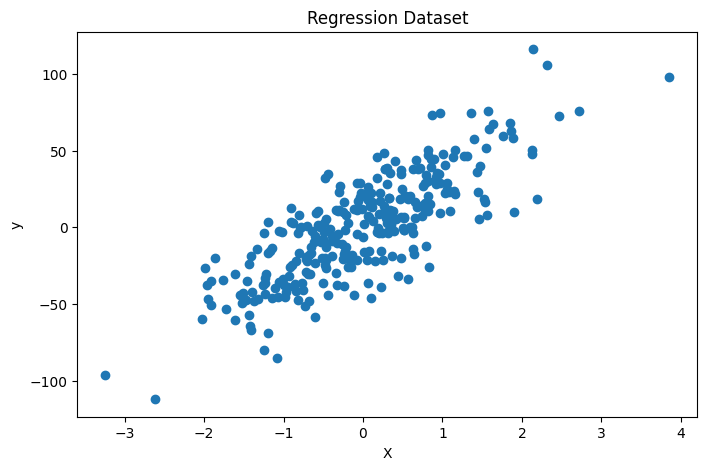

In [4]:
# Visualize Regression Dataset


plt.figure(figsize=(8,5))

plt.scatter(X_reg, y_reg)

plt.title("Regression Dataset")
plt.xlabel("X")
plt.ylabel("y")

plt.show()

In [6]:
# Generate Classification Dataset


X_clf, y_clf = make_classification(
    n_samples=300,
    n_features=4,
    n_classes=2,
    random_state=42
)

print("Classification Dataset Shape:")
print(X_clf.shape)
print(y_clf.shape)

Classification Dataset Shape:
(300, 4)
(300,)


In [7]:
# Train Test Split


X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42
)

#Part 1 — Regression Models

In [9]:
# Linear Regression

linear_model = LinearRegression()

linear_model.fit(X_train_reg, y_train_reg)

y_pred_linear = linear_model.predict(X_test_reg)

linear_mse = mean_squared_error(
    y_test_reg,
    y_pred_linear
)

print("Linear Regression MSE:")
print(linear_mse)

Linear Regression MSE:
426.7511848509342


In [10]:
# Polynomial Regression

poly_model = make_pipeline(
    PolynomialFeatures(degree=3),
    LinearRegression()
)

poly_model.fit(X_train_reg, y_train_reg)

y_pred_poly = poly_model.predict(X_test_reg)

poly_mse = mean_squared_error(
    y_test_reg,
    y_pred_poly
)

print("Polynomial Regression MSE:")
print(poly_mse)

Polynomial Regression MSE:
429.6381541291758


In [11]:
# Polynomial Regression

poly_model = make_pipeline(
    PolynomialFeatures(degree=3),
    LinearRegression()
)

poly_model.fit(X_train_reg, y_train_reg)

y_pred_poly = poly_model.predict(X_test_reg)

poly_mse = mean_squared_error(
    y_test_reg,
    y_pred_poly
)

print("Polynomial Regression MSE:")
print(poly_mse)

Polynomial Regression MSE:
429.6381541291758


In [12]:
# Decision Tree Regressor

tree_reg = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

tree_reg.fit(X_train_reg, y_train_reg)

y_pred_tree = tree_reg.predict(X_test_reg)

tree_mse = mean_squared_error(
    y_test_reg,
    y_pred_tree
)

print("Decision Tree Regressor MSE:")
print(tree_mse)

Decision Tree Regressor MSE:
529.0670986434048


#Part 2 — Classification Models

In [18]:
# Logistic Regression

log_model = LogisticRegression()

log_model.fit(X_train_clf, y_train_clf)

y_pred_log = log_model.predict(X_test_clf)

log_acc = accuracy_score(
    y_test_clf,
    y_pred_log
)

print("Logistic Regression Accuracy:")
print(log_acc)

Logistic Regression Accuracy:
0.9


In [19]:
# Decision Tree Regressor

tree_reg = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

tree_reg.fit(X_train_reg, y_train_reg)

y_pred_tree = tree_reg.predict(X_test_reg)

tree_mse = mean_squared_error(
    y_test_reg,
    y_pred_tree
)

print("Decision Tree Regressor MSE:")
print(tree_mse)

Decision Tree Regressor MSE:
529.0670986434048


In [20]:
# Decision Tree Classifier

tree_clf = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_clf.fit(X_train_clf, y_train_clf)

y_pred_tree_clf = tree_clf.predict(X_test_clf)

tree_acc = accuracy_score(
    y_test_clf,
    y_pred_tree_clf
)

print("Decision Tree Accuracy:")
print(tree_acc)

Decision Tree Accuracy:
0.9166666666666666


In [21]:
# Decision Tree Classifier

tree_clf = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_clf.fit(X_train_clf, y_train_clf)

y_pred_tree_clf = tree_clf.predict(X_test_clf)

tree_acc = accuracy_score(
    y_test_clf,
    y_pred_tree_clf
)

print("Decision Tree Accuracy:")
print(tree_acc)

Decision Tree Accuracy:
0.9166666666666666


In [28]:
# Linear Discriminant Analysis

lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train_clf, y_train_clf)

y_pred_lda = lda_model.predict(X_test_clf)

lda_acc = accuracy_score(
    y_test_clf,
    y_pred_lda
)

print("LDA Accuracy:")
print(lda_acc)

LDA Accuracy:
0.8833333333333333


#Part 3 — Cross Validation


In [29]:
# Cross Validation Regression

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores_reg = cross_val_score(
    linear_model,
    X_reg,
    y_reg,
    cv=kf,
    scoring='neg_mean_squared_error'
)

cv_scores_reg = -cv_scores_reg

print("Cross Validation MSE Scores:")
print(cv_scores_reg)

print("Average CV MSE:")
print(cv_scores_reg.mean())

Cross Validation MSE Scores:
[426.75118485 349.37603758 273.91141129 595.19923335 426.60528677]
Average CV MSE:
414.36863076871515


In [30]:
# Cross Validation Classification

cv_scores_clf = cross_val_score(
    log_model,
    X_clf,
    y_clf,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Accuracy Scores:")
print(cv_scores_clf)

print("Average Accuracy:")
print(cv_scores_clf.mean())

Cross Validation Accuracy Scores:
[0.95       0.93333333 0.88333333 0.95       0.9       ]
Average Accuracy:
0.9233333333333335


#Part 4 — Bootstrap


In [31]:
# Bootstrap Regression

bootstrap_errors = []

for i in range(100):

    X_boot, y_boot = resample(
        X_train_reg,
        y_train_reg,
        replace=True
    )

    linear_model.fit(X_boot, y_boot)

    y_pred = linear_model.predict(X_test_reg)

    mse = mean_squared_error(
        y_test_reg,
        y_pred
    )

    bootstrap_errors.append(mse)

print("Bootstrap Mean Error:")
print(np.mean(bootstrap_errors))

Bootstrap Mean Error:
430.2091759743039


In [32]:
# Classification Metrics

precision = precision_score(
    y_test_clf,
    y_pred_log
)

recall = recall_score(
    y_test_clf,
    y_pred_log
)

f1 = f1_score(
    y_test_clf,
    y_pred_log
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.90625
Recall: 0.90625
F1 Score: 0.90625


#Part 5 — Visualization


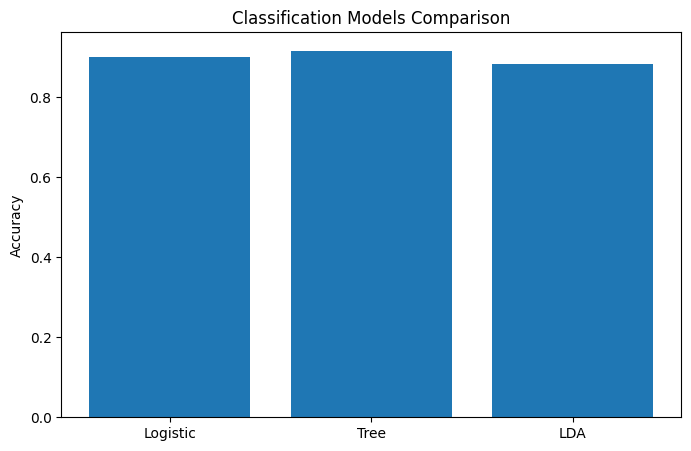

In [33]:
# Compare Classification Models

models = ['Logistic', 'Tree', 'LDA']

accuracies = [
    log_acc,
    tree_acc,
    lda_acc
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Classification Models Comparison")
plt.ylabel("Accuracy")

plt.show()

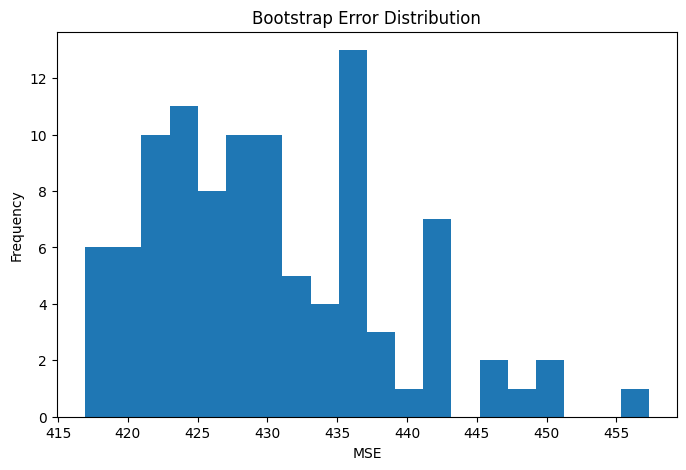

In [34]:
# Bootstrap Error Distribution

plt.figure(figsize=(8,5))

plt.hist(
    bootstrap_errors,
    bins=20
)

plt.title("Bootstrap Error Distribution")
plt.xlabel("MSE")
plt.ylabel("Frequency")

plt.show()